本节结束后您将能够回答的问题：
- 如何识别代码中的速度和RAM瓶颈？
- 如何分析CPU和内存使用情况？
- 我应该使用什么深度的分析？
- 如何分析长期运行的应用程序？
- 在CPython下面发生了什么事？
- 如何在调整性能时保持代码正确？

Profiling 分析可以让我们找到瓶颈，这样我们就可以做最少的工作来获得最大的实际性能增益。虽然我们希望在速度上获得巨大的收益，并在资源使用上减少一些工作量，但实际上目标是让代码运行“足够快”和“足够瘦”，以满足需求。Profiling 分析将让您以最少的总体努力做出最务实的决策。

可以分析任何可测量的资源（不仅仅是CPU！）。在本节中，我们将介绍CPU时间和内存使用情况。您也可以应用类似的技术来测量网络带宽和磁盘I/O。

如果一个程序运行太慢或使用太多的RAM，您需要修复代码中负责的部分。当然，可以跳过分析，修复您认为可能存在的问题，但要小心，因为最终会“修复”错误的东西。与使用直觉相比，在对代码结构进行更改之前，在定义了一个假设之后，首先进行概要分析要明智得多。

有时候懒惰是好事。通过首先分析，可以快速确定需要解决的瓶颈，然后就可以解决其中的足够多的瓶颈，以实现所需的性能。如果避免分析并跳转到优化，那么从长远来看，很可能会做更多的工作。总是被分析的结果所驱动。

## Profiling 有效分析

Profiling的第一个目的是测试一个有代表性的系统，以确定什么是慢的（或者使用太多的RAM，或者导致太多的磁盘I/O或网络I/O）。Profiling分析通常会增加开销（可能是典型的慢10到100倍），并且仍然希望代码在尽可能类似于实际情况的情况下使用。提取一个测试用例并隔离需要测试的系统部分。最好，它已经被写在自己的一组模块中了。

本节首先介绍的基本技术包括IPython中的 %timeit 、time.time() 和计时装饰器。您可以使用这些技术来理解语句和函数的行为。

然后我们将介绍 cProfile（“使用cProfile模块”），向您展示如何使用此内置工具来了解代码中运行时间最长的函数。这将为您提供问题的高级视图，以便您可以将注意力集中到关键功能上。

下一步，我们将研究line_profiler（“使用line_profiler进行逐行测量”），它将逐行分析所选函数。结果将包括每一行被调用的次数和每一行花费的时间百分比。这正是你需要的信息，以了解什么是运行缓慢，为什么?

有了 line_profiler 的结果，您将获得继续使用编译器所需的信息.

我们还将学习如何使用 perf_stat 来了解最终在CPU上执行的指令数以及CPU缓存的利用效率。这允许对矩阵操作进行高级调优。

在line_profiler之后，如果使用的是长时间运行的系统，那么将对 pyspy 感兴趣，以便深入了解已经运行的Python进程。

为了帮助理解RAM使用率高的原因，我们将展示 memor_profiler（“使用memory_profiler诊断内存使用情况”）。它特别适用于在标记的图表上跟踪一段时间内的RAM使用情况，因此可以解释为什么某些函数使用的RAM比预期的要多。

接下来，我们将向您介绍CPython中的Python字节码（“使用  dis模块检查CPython字节码”），这样就可以了解“引擎盖下”发生了什么，了解Python基于堆栈的虚拟机是如何运行的，这将有助于理解为什么某些编码样式运行得比其他样式慢。

在本节结束之前，我们将回顾如何在分析时集成单元测试（“在优化过程中进行单元测试以保持正确性”），从而在提高代码运行效率的同时保持代码的正确性。

最后我们将讨论评测策略（“成功评测代码的策略”），这样您就可以可靠地评测代码并收集正确的数据来测试您的假设。在这里，将了解动态CPU频率缩放和turboboost等功能如何影响分析结果，以及如何禁用它们。

要完成所有这些步骤，我们需要一个易于分析的函数。下一节介绍Julia集。它是一个CPU限制的函数，对RAM有点饥渴；它还表现出非线性行为（因此我们不容易预测结果），这意味着我们需要在运行时分析它，而不是离线分析它。

## Julia集概述

Julia集是一个有趣的CPU受限问题。它是一个分形序列，生成一个复杂的输出图像，以加 Gaston Julia 命名。

下面的代码比您自己可能编写的版本长一点。它有一个CPU绑定的组件和一组非常明确的输入。这种配置允许我们分析CPU使用情况和RAM使用情况，这样我们就可以了解代码的哪些部分正在消耗我们稀缺的两种计算资源。这个实现是故意次优的，所以我们可以识别内存消耗操作和慢语句。在本节后面，我们将修复一个慢逻辑语句和一个内存消耗语句，在第7节中 我们将大大加快这个函数的整体执行时间。

我们将分析一个代码块，该代码块同时生成一个假灰度图（左图）和Julia集的纯灰度变量（右图 ），在复点c=-0.62772-0.42193j。通过孤立地计算每个像素来产生Julia集；这是一个“令人尴尬的平行问题”，因为点之间没有共享数据。

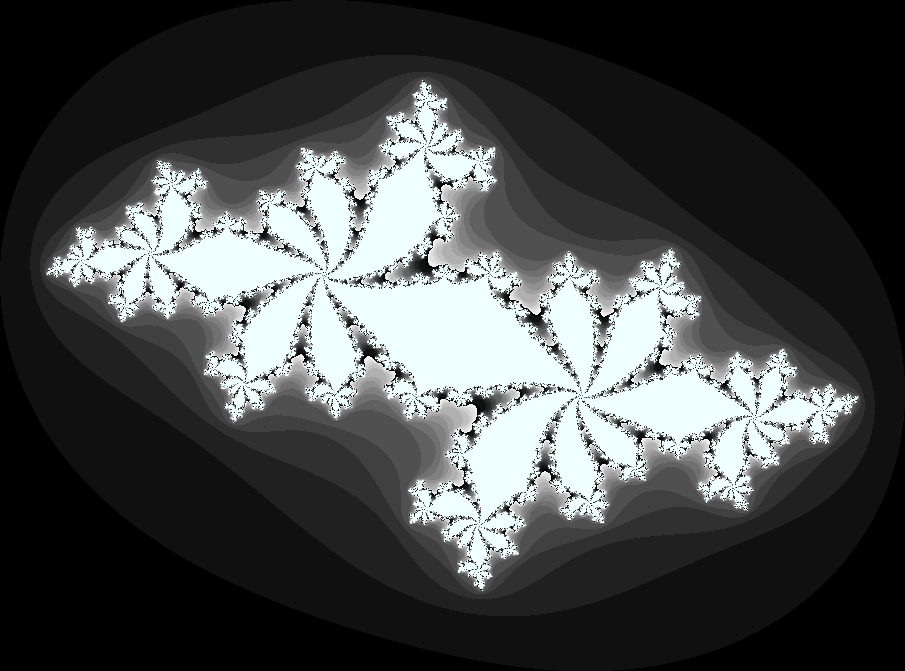

如果我们选择了不同的c，我们会得到一个不同的图像。我们选择的位置有快速计算的区域和其他计算速度较慢的区域；这对我们的分析很有用。

这个问题很有趣，因为我们通过应用一个循环来计算每个像素，循环可以应用一个不确定的次数。在每次迭代中，我们都测试这个坐标的值是否会向无穷远，或者它似乎被吸引子所保持。导致很少迭代的坐标在图中被涂成黑色，那些导致大量迭代的是白色的。白区域计算更复杂，因此生成所需时间更长。
我们定义一组z坐标，我们将测试。我们计算复数z和添加c的函数：

$$f(z) = z^2 + c $$

我们在测试时迭代这个函数，以查看是否使用abs保持逃逸条件。如果转义函数为False，则我们将退出循环，并记录在这个坐标下执行的迭代次数。如果转义函数从不为False，则在maxiter迭代之后停止。我们稍后将把z的结果转换为一个表示这个复杂位置的彩色像素。

在伪代码中，它可能如下所示：

为了解释这个函数，让我们尝试两个坐标。

我们将使用在图的左上角-1.8-1.8j处绘制的坐标。我们必须先测试abs（z）<2，然后才能尝试更新规则：

In [1]:
z = -1.8-1.8j
print(abs(z))

2.545584412271571


我们可以看到，对于左上角坐标，abs（z）测试在第0次迭代时将为False，即2.54>=2.0，因此我们不执行更新规则。此坐标的输出值为0。

现在让我们跳到z=0+0j处的绘图中心，并尝试几次迭代：

In [2]:
c = -0.62772-0.42193j
z = 0+0j
for n in range(9):
    z = z*z + c
    print(f"{n}: z={z: .5f}, abs(z)={abs(z):0.3f}, c={c: .5f}")

0: z=-0.62772-0.42193j, abs(z)=0.756, c=-0.62772-0.42193j
1: z=-0.41171+0.10778j, abs(z)=0.426, c=-0.62772-0.42193j
2: z=-0.46983-0.51068j, abs(z)=0.694, c=-0.62772-0.42193j
3: z=-0.66777+0.05793j, abs(z)=0.670, c=-0.62772-0.42193j
4: z=-0.18516-0.49930j, abs(z)=0.533, c=-0.62772-0.42193j
5: z=-0.84274-0.23703j, abs(z)=0.875, c=-0.62772-0.42193j
6: z= 0.02630-0.02242j, abs(z)=0.035, c=-0.62772-0.42193j
7: z=-0.62753-0.42311j, abs(z)=0.757, c=-0.62772-0.42193j
8: z=-0.41295+0.10910j, abs(z)=0.427, c=-0.62772-0.42193j


我们可以看到，对于这些第一次迭代，每次对z的更新都会留下一个值，其中abs（z）<2是真的。对于这个坐标，我们可以迭代300次，测试仍然是真的。在条件变为False之前，我们无法判断必须执行多少次迭代，这可能是一个无限序列。maximum iteration（maxiter）break子句将阻止我们永远进行迭代。

在下图中，我们看到前面序列的前50次迭代。对于0+0j（带圆标记的实线），序列似乎每第8次迭代就重复一次，但是每7次计算的序列都与前一次的序列有一个微小的偏差，我们无法判断这一点是否会在边界条件内永远迭代，或者很长时间，或者可能只是再迭代几次。虚线表示+2处的边界。

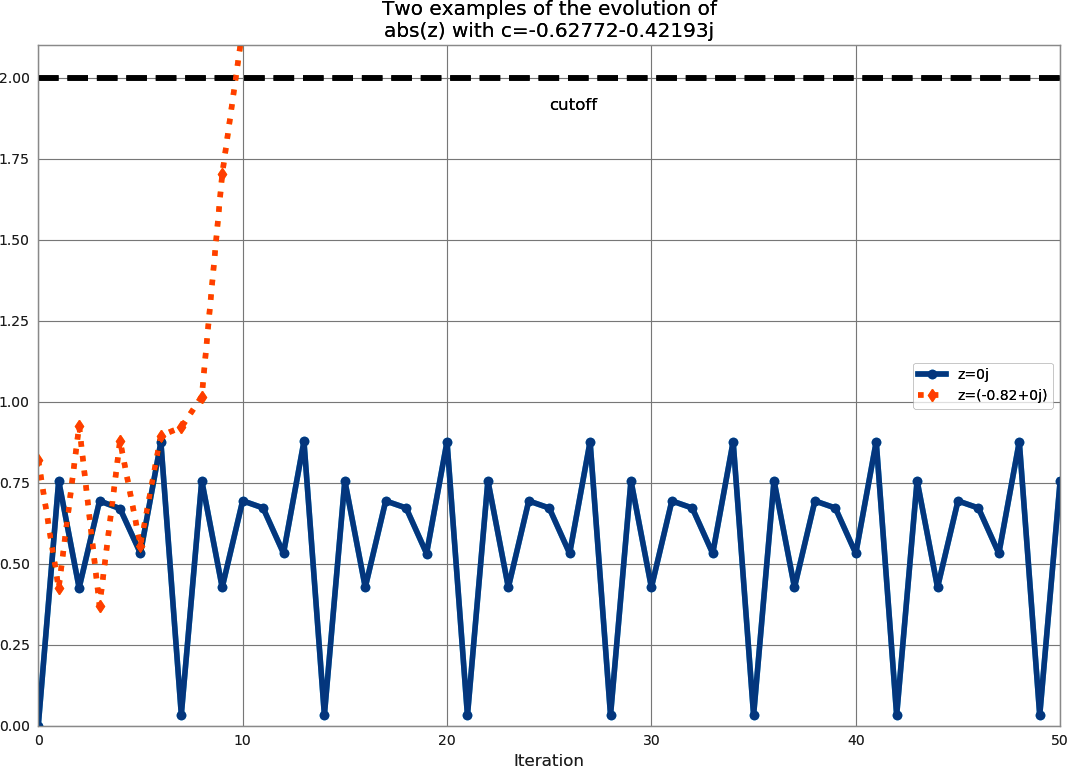

Julia集演化的两个坐标例子

对于-0.82+0j（带菱形标记的虚线），我们可以看到在第9次更新之后，绝对结果已经超过了+2截止值，因此我们停止更新这个值。

### 计算全Julia集

在本节中，我们将分解生成Julia集的代码。我们将以各种方式对其进行分析。如示例所示 2-1，在我们的模块开始时，我们为我们的第一个分析方法导入时间模块，并定义一些坐标常数。

例2-1：定义坐标空间的全局常量

In [3]:
"""Julia set generator without optional PIL-based image drawing"""
import time

# area of complex space to investigate
x1, x2, y1, y2 = -1.8, 1.8, -1.8, 1.8
c_real, c_imag = -0.62772, -.42193

例2-2:建立坐标表作为计算函数的输入

In [4]:
def calc_pure_python(desired_width, max_iterations):
    """Create a list of complex coordinates (zs) and complex parameters (cs),
    build Julia set"""
    x_step = (x2 - x1) / desired_width
    y_step = (y1 - y2) / desired_width
    x = []
    y = []
    ycoord = y2
    while ycoord > y1:
        y.append(ycoord)
        ycoord += y_step
    xcoord = x1
    while xcoord < x2:
        x.append(xcoord)
        xcoord += x_step
    # build a list of coordinates and the initial condition for each cell.
    # Note that our initial condition is a constant and could easily be removed,
    # we use it to simulate a real-world scenario with several inputs to our
    # function
    zs = []
    cs = []
    for ycoord in y:
        for xcoord in x:
            zs.append(complex(xcoord, ycoord))
            cs.append(complex(c_real, c_imag))

    print("Length of x:", len(x))
    print("Total elements:", len(zs))
    start_time = time.time()
    output = calculate_z_serial_purepython(max_iterations, zs, cs)
    end_time = time.time()
    secs = end_time - start_time
    print(calculate_z_serial_purepython.__name__ + " took", secs, "seconds")

    # This sum is expected for a 1000^2 grid with 300 iterations
    # It ensures that our code evolves exactly as we'd intended
    assert sum(output) == 33219980

在构建了zs和cs列表之后，我们输出了一些关于列表大小的信息，并通过calculate z_serial_purepython计算输出列表。最后，我们对输出的内容求和并断言它与预期的输出值匹配。

由于代码是确定性的，我们可以通过对所有计算值求和来验证函数是否按预期工作。当我们对数值代码进行更改时，这是一个有用的健全性检查，检查我们没有破坏算法是非常明智的。理想情况下，我们将使用单元测试并测试问题的多个配置。

接下来，举个例子 2-3，我们定义了calculate_z_serial_purepython函数，它扩展了前面讨论的算法。值得注意的是，我们还在开始处定义了一个与输入zs和cs列表长度相同的输出列表。

例2-3。我们的CPU限制计算函数

In [5]:
def calculate_z_serial_purepython(maxiter, zs, cs):
    """Calculate output list using Julia update rule"""
    output = [0] * len(zs)
    for i in range(len(zs)):
        n = 0
        z = zs[i]
        c = cs[i]
        while abs(z) < 2 and n < maxiter:
            z = z * z + c
            n += 1
        output[i] = n
    return output

现在我们在示例中调用计算例2-4. 通过将其包装在一个 __main__ 检查中，我们可以安全地导入模块，而不必为某些分析方法启动计算。这里，我们没有显示用于打印输出的方法。

示例:2-4。main代码

In [6]:
if __name__ == "__main__":
    # Calculate the Julia set using a pure Python solution with
    # reasonable defaults for a laptop
    calc_pure_python(desired_width=1000, max_iterations=300)

Length of x: 1000
Total elements: 1000000
calculate_z_serial_purepython took 12.265259742736816 seconds


在假灰度图中，高对比度的颜色变化让我们知道功能的成本是缓慢变化还是快速变化。这里，在下图中，我们有一个线性彩色地图：黑色是快速计算，白色是昂贵的计算。

通过显示相同数据的两种表示，我们可以看到线性映射中丢失了大量细节。有时，在研究函数的代价时，考虑各种表示法是有用的。

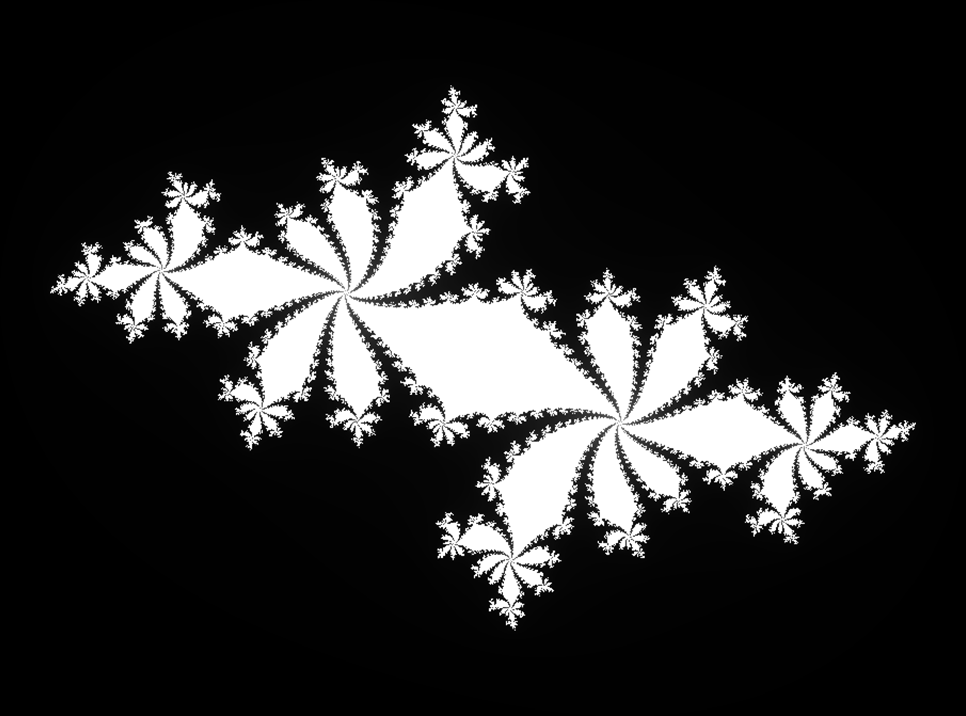

### 使用Unix time命令进行简单计时

我们可以暂时跳出Python，在类Unix系统上使用标准系统实用程序。以下内容将记录有关程序执行时间的各种视图，而不关心代码的内部结构：

请注意，我们专门使用/usr/bin/time而不是time，因此我们得到的是系统的时间，而不是shell中内置的更简单（也不太有用）的版本。如果您尝试 `time --verbose`，您可能看到的是shell的内置time命令，而不是系统命令。

使用-p可移植性标志，我们得到三个结果：
- real 记录挂钟或经过的时间。
- user 记录CPU在内核函数之外的任务上花费的时间。
- sys 记录在内核级函数中花费的时间。

通过添加user和sys，您可以了解在CPU中花费了多少时间。这个和real的区别可能会告诉您等待I/O所花费的时间；这也可能表明您的系统正忙于运行其他会扭曲您的度量的任务。

时间是有用的，因为它不是特定于Python的。它包括启动python可执行文件所需的时间，如果启动许多新进程（而不是长时间运行的单个进程），这可能非常重要。如果您经常有短时间运行的脚本，其中启动时间是整个运行时的重要部分，那么时间可以是一个更有用的度量。

我们可以添加 --verbose 标志来获得更多的输出：

这里最有用的指标可能是 Major (requiring I/O) page faults，因为这表明操作系统是否必须从磁盘加载数据页，因为数据不再驻留在RAM中。这将导致速度损失。

在我们的示例中，代码和数据需求很小，因此不会出现页面错误。如果您有一个内存受限的进程，或者有几个程序使用可变的和大量的RAM，那么您可能会发现，这提供了一个线索，说明哪个程序在操作系统级别被磁盘访问减慢了速度，因为它的一部分已经从RAM换到了磁盘。

## 使用cProfile模块

cProfile是标准库中的内置评测工具。它在CPython中连接到虚拟机中，以测量运行它看到的每个函数所花费的时间。这会带来更大的开销，但您可以得到相应的更多信息。有时，额外的信息可能会导致对代码的惊人见解。

cProfile是标准库中的两个探查器之一，与概要文件一起。profile是原始的、较慢的纯Python探查器；cProfile与概要文件具有相同的接口，并用C编写，以降低开销。

分析时的一个好做法是在您配置代码之前生成一个关于代码部分速度的假设。提前形成假设意味着你可以测量你有多错误提高你对某些编码风格的直觉。

总是被你测量的结果所驱动，并且总是从一些快速而肮脏的分析开始，以确保你在正确的领域进行了处理。没有什么比聪明地优化一段代码而仅仅意识到（几小时或几天之后）错过了流程中最慢的部分，并且根本没有真正解决根本问题更令人谦卑的了。

让我们假设 `calculate_z_serial_purepython` 是代码中最慢的部分。在这个函数中，我们进行了大量的解引用，并调用了许多基本的算术运算符和abs函数。它们可能会以CPU资源的消费者的身份出现。

在这里，我们将使用cProfile模块来运行代码的变体。输出是斯巴达式的，但有助于我们找到进一步分析的地方。

-s cumulative 标志告诉cProfile按每个函数内花费的累计时间排序；这使我们可以看到代码段中最慢的部分。cProfile输出在我们通常的打印结果之后直接写入屏幕：

按累积时间排序可以让我们了解大部分执行时间的使用地点。这个结果显示3622995函数调用在12秒以上发生（这次包括使用cProfile的开销）。以前，我们的代码执行大约8秒，我们刚刚添加了4秒的惩罚，通过测量每个函数执行所需的时间。

我们可以看到，第1行上的代码julia1_unopil.py的入口点总共需要12秒。这只是对calc_uuPure_uuPython的调用。nCALL为1，表示仅执行一次该行。

在calc_uPurePython中，计算 calculate_z_serial_purepython 的调用需要11秒。这两个函数都只调用一次。我们可以得出，大约1秒用于calc_upurepython中的代码行，单独调用CPU密集型 calculate_z_serial_purepython 函数。但是，我们无法使用cProfile来推导函数内需要花费时间的行。

在计算 calculate_z_serial_purepython 中，在代码行上花费的时间（不调用其他函数）为8秒。此功能对abs进行34219980次调用，总共需要3秒，以及其他不花费太多时间的调用。

{abs}调用呢？这一行测量了对 calculate_z_serial_purepython 中abs函数的单独调用。虽然每次调用成本可以忽略不计（记录为0.000秒），34219980次呼叫的总时间为3秒。我们无法预先预测abs会有多少调用，因为Julia函数具有不可预测的动态性（这就是为什么我们这么感兴趣地看）。

我们最多可以说它至少会被称为100万次，因为我们计算的是`1000*1000`像素。最多将被称为3亿次，因为我们计算了1000000像素，最多300次迭代。因此，3400万的调用约占最坏情况的10%。

如果我们看原始灰度图像在我们的脑海中，把白色的部分挤压在一起，然后再挤到一个角落，我们可以估计，昂贵的白色区域大约占图像其余部分的10%。

在配置文件输出中的下一行，`{method 'append' of 'list' objects}` ，详细介绍2002000列表项的创建。

创建 2,002,000 项是在安装阶段的 calc_pure_python 中发生的。

zs和cs列表将是 `1000*1000` 个项目，每个项目（生成`1000000*2` 个调用），这些项是由1000 x和1000 y坐标组成的。总共，这是要追加的2002000个调用。

必须注意，此cProfile输出不是由父函数排序的；它正在汇总执行代码块中所有函数的费用。通过cProfile，很难逐行地找出发生的事情，因为我们只为函数调用自己而不是函数中的每一行获取概要信息。

在计算{abs}的内部计算 calculate_z_serial_purepython，我们可以计算{abs}，并且这个函数总共花费大约3.1秒。我们知道计算calculate_z_serial_purepython 总共需要11.4秒。

分析输出的最后一行是lsprof；这是工具的原始名称，它演变成cProfile，可以忽略。

为了获得对cProfile结果的更多控制，我们可以编写一个统计文件，然后用Python分析它：

In [7]:
!python -m cProfile -o profile.stats julia1.py

Length of x: 1000
Total elements: 1000000
calculate_z_serial_purepython took 15.122405767440796 seconds
300.0


我们可以将其加载到Python中，如下所示，它将为我们提供与以前相同的累计时间报告：

In [8]:
import pstats

p = pstats.Stats("profile.stats")
p.sort_stats("cumulative")

In [9]:
p.print_stats()

Thu Apr 29 20:53:47 2021    profile.stats

         36250581 function calls (36249708 primitive calls) in 19.045 seconds

   Ordered by: cumulative time

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
     69/1    0.001    0.000   19.045   19.045 {built-in method builtins.exec}
        1    0.059    0.059   19.045   19.045 julia1.py:1(<module>)
        1    0.786    0.786   18.471   18.471 julia1.py:59(calc_pure_python)
        1    9.940    9.940   15.126   15.126 julia1.py:45(calculate_z_serial_purepython)
 34219980    5.186    0.000    5.186    0.000 {built-in method builtins.abs}
        1    0.047    0.047    2.369    2.369 julia1.py:11(show_greyscale)
        1    0.000    0.000    1.983    1.983 D:\ProgramData\Miniconda3\lib\site-packages\PIL\Image.py:2182(show)
        1    0.000    0.000    1.983    1.983 D:\ProgramData\Miniconda3\lib\site-packages\PIL\Image.py:3152(_show)
        1    0.000    0.000    1.983    1.983 D:\ProgramData\Miniconda3\lib\site

      320    0.000    0.000    0.000    0.000 <frozen importlib._bootstrap>:321(<genexpr>)
        1    0.000    0.000    0.000    0.000 D:\ProgramData\Miniconda3\lib\tempfile.py:159(_candidate_tempdir_list)
        1    0.000    0.000    0.000    0.000 D:\ProgramData\Miniconda3\lib\pathlib.py:1005(Path)
      154    0.000    0.000    0.000    0.000 D:\ProgramData\Miniconda3\lib\sre_parse.py:160(__len__)
      103    0.000    0.000    0.000    0.000 D:\ProgramData\Miniconda3\lib\sre_parse.py:286(tell)
       85    0.000    0.000    0.000    0.000 <frozen importlib._bootstrap>:143(__init__)
        7    0.000    0.000    0.000    0.000 D:\ProgramData\Miniconda3\lib\site-packages\PIL\TiffImagePlugin.py:635(_register_basic)
       28    0.000    0.000    0.000    0.000 D:\ProgramData\Miniconda3\lib\sre_compile.py:423(_simple)
        1    0.000    0.000    0.000    0.000 D:\ProgramData\Miniconda3\lib\threading.py:1185(__init__)
      179    0.000    0.000    0.000    0.000 {built-in metho

        7    0.000    0.000    0.000    0.000 {built-in method sys.intern}
        2    0.000    0.000    0.000    0.000 {built-in method math.log}
       12    0.000    0.000    0.000    0.000 <frozen importlib._bootstrap>:765(is_package)
        2    0.000    0.000    0.000    0.000 D:\ProgramData\Miniconda3\lib\enum.py:152(<dictcomp>)
       11    0.000    0.000    0.000    0.000 D:\ProgramData\Miniconda3\lib\enum.py:623(name)
        1    0.000    0.000    0.000    0.000 D:\ProgramData\Miniconda3\lib\traceback.py:227(FrameSummary)
        1    0.000    0.000    0.000    0.000 D:\ProgramData\Miniconda3\lib\threading.py:204(Condition)
        1    0.000    0.000    0.000    0.000 D:\ProgramData\Miniconda3\lib\numbers.py:267(Rational)
        1    0.000    0.000    0.000    0.000 D:\ProgramData\Miniconda3\lib\_compression.py:33(DecompressReader)
        1    0.000    0.000    0.000    0.000 D:\ProgramData\Miniconda3\lib\urllib\parse.py:142(_NetlocResultMixinBase)
        1    0.000   

为了跟踪我们正在分析的函数，我们可以打印调用方信息。在下面的两个清单中，我们可以看到，calculate_z_serial_purepython 是最昂贵的函数，它是从一个地方调用的。如果从许多地方调用，这些列表可能会帮助我们缩小最贵父系的位置：

In [10]:
p.print_callers()

   Ordered by: cumulative time

Function                                                                                       was called by...
                                                                                                   ncalls  tottime  cumtime
{built-in method builtins.exec}                                                                <-    61/8    0.000    0.604  <frozen importlib._bootstrap>:211(_call_with_frames_removed)
                                                                                                        7    0.001    0.001  D:\ProgramData\Miniconda3\lib\collections\__init__.py:316(namedtuple)
julia1.py:1(<module>)                                                                          <-       1    0.059   19.045  {built-in method builtins.exec}
julia1.py:59(calc_pure_python)                                                                 <-       1    0.786   18.471  julia1.py:1(<module>)
julia1.py:45(calculate_z_serial_purepython)    

D:\ProgramData\Miniconda3\lib\site-packages\PIL\TiffImagePlugin.py:628(_register_writer)       <-       5    0.000    0.000  D:\ProgramData\Miniconda3\lib\site-packages\PIL\TiffImagePlugin.py:400(ImageFileDirectory_v2)
D:\ProgramData\Miniconda3\lib\site-packages\PIL\PpmImagePlugin.py:47(PpmImageFile)             <-       1    0.000    0.000  {built-in method builtins.__build_class__}
D:\ProgramData\Miniconda3\lib\site-packages\PIL\PngImagePlugin.py:202(iTXt)                    <-       1    0.000    0.000  {built-in method builtins.__build_class__}
D:\ProgramData\Miniconda3\lib\site-packages\PIL\PngImagePlugin.py:224(PngInfo)                 <-       1    0.000    0.000  {built-in method builtins.__build_class__}
{built-in method nt.getpid}                                                                    <-       2    0.000    0.000  D:\ProgramData\Miniconda3\lib\tempfile.py:142(rng)
{method 'release' of '_thread.RLock' objects}                                                  <-    

我们可以将其反过来显示哪些函数调用其他函数：

In [11]:
p.print_callees()

   Ordered by: cumulative time

Function                                                                                       called...
                                                                                                   ncalls  tottime  cumtime
{built-in method builtins.exec}                                                                ->       1    0.000    0.000  <string>:1(<module>)
                                                                                                        1    0.000    0.000  D:\ProgramData\Miniconda3\lib\_compression.py:1(<module>)
                                                                                                        1    0.000    0.000  D:\ProgramData\Miniconda3\lib\bisect.py:1(<module>)
                                                                                                        1    0.000    0.005  D:\ProgramData\Miniconda3\lib\bz2.py:5(<module>)
                                                           

D:\ProgramData\Miniconda3\lib\site-packages\PIL\Image.py:3075(register_save_all)               ->       3    0.000    0.000  {method 'upper' of 'str' objects}
D:\ProgramData\Miniconda3\lib\logging\__init__.py:711(Filterer)                                -> 
D:\ProgramData\Miniconda3\lib\traceback.py:437(TracebackException)                             -> 
D:\ProgramData\Miniconda3\lib\tokenize.py:108(any)                                             ->       1    0.000    0.000  D:\ProgramData\Miniconda3\lib\tokenize.py:107(group)
D:\ProgramData\Miniconda3\lib\string.py:78(Template)                                           -> 
D:\ProgramData\Miniconda3\lib\string.py:175(Formatter)                                         -> 
D:\ProgramData\Miniconda3\lib\tempfile.py:233(_get_candidate_names)                            ->       1    0.000    0.000  {method 'acquire' of '_thread.lock' objects}
                                                                                                 

cProfile相当冗长，您需要一个侧屏幕来查看它，而不需要大量的文档。不过，由于它是内置的，所以它是一个快速识别瓶颈的方便工具。像line_profiler和 memory_profiler 这样的工具，我们将在本节稍后讨论，它们将帮助您深入到您应该注意的特定行。

### 使用SnakeViz可视化cProfile输出

SnakeViz是一个可视化工具，它将cProfile的输出绘制为一个图表，在这个图表中，较大的框是运行时间较长的代码区域。它取代了旧的runsnake工具。
使用SnakeViz可以对cProfile统计文件有一个高层次的了解，特别是当你正在调查一个你几乎没有直觉的新项目时。该图将帮助您可视化系统的CPU使用行为，并且它可能会突出显示您不希望昂贵的区域。

In [13]:
!pip install snakeviz --user

Looking in indexes: http://pypi.douban.com/simple/


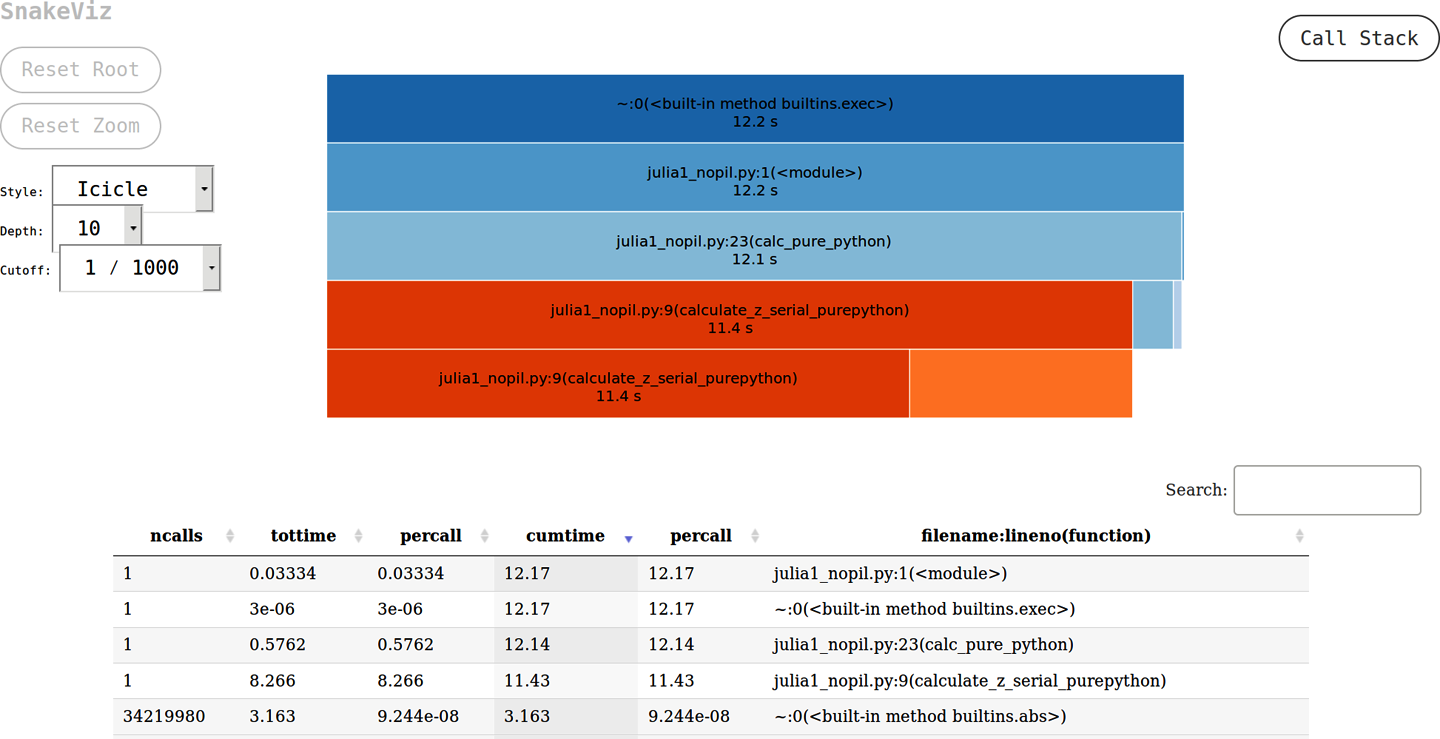

下一节将显示一个表格，它是我们刚才看到的统计数据的一个打印版本，您可以按cumtime（累计时间）、percall（每次调用的成本）或ncalls（总共调用的次数）以及其他类别进行排序。从cumtime开始，它会告诉你哪些函数的成本最高。他们是你开始调查的好地方。

如果您可以轻松地查看表，那么cProfile的控制台输出可能就足够了。为了与他人交流，我们强烈建议您使用snakeviz的输出这样的图表来帮助他人快速理解您的观点。

### 使用line_profiler逐线测量

robertkern的行分析器是确定Python代码中CPU受限问题原因的最强工具。它是通过逐行分析单个函数来工作的，因此您应该从cProfile开始，并使用高级视图来指导使用 line_profiler 分析哪些函数。

当您修改代码时，打印和注释这个工具输出的版本是值得的，这样您就有了一个可以快速引用的更改记录（成功与否）。当你在做一行一行的改变时，不要依赖你的记忆。

In [ ]:
!pip install line_profiler

decorator（@profile）用于标记所选函数。kernprof脚本用于执行代码，并记录所选函数每行的CPU时间和其他统计信息。

参数为 -l 表示逐行（而不是函数级）评测，为 -v 表示详细输出。如果没有 -v，您将收到一个 .lprof 输出，您可以稍后使用 line_profiler 模块进行分析。在示例中 2-6，我们将对CPU绑定的函数进行一次完整的运行。

例2-6。在修饰函数上逐行运行kernprof以记录每行执行的CPU开销

In [ ]:
!kernprof -l -v julia1_lineprofiler.py

引入kernprof.py为运行时添加了大量内容。在这个例子中，calculate_z_serial_purepython需要49秒；这比使用简单打印语句的8秒和使用cProfile的12秒有所提高。这样做的好处是，我们可以得到一行一行的函数内部时间的细分。

% Time 列是最有用的，我们可以看到38%的时间花在while测试上。但是，我们不知道第一个语句（abs（z）<2）是否比第二个语句（n<maxiter）更昂贵。在循环中，我们看到对z的更新也相当昂贵。即使n+=1也很贵！Python的动态查找机制对每个循环都起作用，即使我们对每个循环中的每个变量使用相同的类型，这也是编译和类型专门化的地方给我们一个巨大的胜利。与while循环的成本相比，在第20行创建输出列表和更新相对便宜。

如果您以前没有考虑过Python动态机制的复杂性，那么请考虑n+=1操作中会发生什么。Python必须检查n对象是否有一个 __add__ 函数（如果没有，它将遍历所有继承的类，看看它们是否提供了这个功能），然后传入另一个对象，以便 __add__ 函数可以决定如何处理该操作。请记住，第二个参数可能是float或其他可能兼容或不兼容的对象。这一切都是动态发生的。

进一步分析while语句的明显方法是将其分解。虽然Python社区中围绕着使用更详细的多部分单行语句信息重写.pyc文件的想法进行了一些讨论，但我们不知道有任何生产工具提供了比 line_profiler 更细粒度的分析。

在示例中 2-7，我们把while逻辑分成几个语句。这种额外的复杂性将增加函数的运行时，因为我们有更多的代码行要执行，但它也可能帮助我们理解这部分代码所产生的成本。

例2-7。将复合while语句分解为单独的语句，以记录原始语句每个部分的成本

In [ ]:
!kernprof -l -v julia1_lineprofiler2.py

此版本的执行时间为82秒，而上一版本的执行时间为49秒。其他因素确实使分析复杂化。在这种情况下，有额外的语句必须执行34219980次，每一次都会减慢代码的速度。如果我们没有使用kernprof.py来研究这种变化的逐行效应，我们可能会得出关于经济放缓原因的其他结论，因为我们缺乏必要的证据。

在这一点上，有必要回到早期的timeit技术来测试单个表达式的开销：

In [ ]:
z = 0+0j
%timeit abs(z) < 2

In [ ]:
n = 1
maxiter = 300
%timeit n < maxiter

从这个简单的分析中，看起来n上的逻辑测试比调用abs快两倍多。由于Python语句的求值顺序是从左到右的，而且是机会主义的，所以在方程的左侧放置最便宜的测试是有意义的。在每个坐标的301个测试中，1个测试都是False，因此Python不需要评估and操作符的另一端。

我们在评估abs（z）<2之前，永远不知道它是否为假，而我们先前对这个复杂平面区域的观测表明，在所有300次迭代中，大约10%的时间是真的。如果我们想对代码这一部分的时间复杂性有一个很强的了解，那么继续进行数值分析是有意义的。然而，在这种情况下，我们希望能简单地检查一下我们是否能快速获胜。

我们可以形成一个新的假设，即“通过交换while语句中的操作符的顺序，我们将实现一个可靠的加速。”我们可以使用kernprof来检验这个假设，但是这种方法的额外开销可能会增加太多的噪声。相反，我们可以使用早期版本的代码，运行一个测试，比较abs（z）<2和n<maxiter:within n<maxiter和abs（z）<2:，我们在示例中看到 2-8.

在第_u行探查器之外运行这两个变体意味着它们以类似的速度运行。第_uProfiler行的开销也会混淆结果，第17行中两个版本的结果都是相似的。我们应该拒绝这样一个假设，即在Python3.7中，改变逻辑顺序会导致一致的加速，没有明确的证据证明这一点。Ian指出，使用Python2.7我们可以接受这个假设，但是对于Python3.7，情况不再如此。

使用更合适的方法解决此问题（例如，如第章所述，使用Cython或PyPy交换 7） 会带来更大的收益。

我们可以对我们的结果充满信心，因为：
- 我们提出了一个易于检验的假设。
- 我们改变了代码，这样就只测试假设（永远不要一次测试两件事！）。
- 我们收集了足够的证据来支持我们的结论。

为了完整性，我们可以在两个主要函数上运行一个最终的内核prof，包括优化，以确认我们对代码的总体复杂性有一个完整的了解。

示例2-8。在语句的同时交换复合的顺序，使函数的速度分馏更快

In [ ]:
!kernprof -l -v julia1_lineprofiler3.py

正如预期的那样，我们可以从示例中的输出中看到 2-9计算 calculate_z_serial_purepython 占用了其父函数的大部分时间（97%）。相比之下，创建列表的步骤是次要的。

例2-9。测试设置例程的逐行成本

line_profiler 让我们深入了解了循环和昂贵函数中的行的成本；尽管评测会增加速度损失，但对科学开发人员来说却是一大福音。记住要使用有代表性的数据来确保你的注意力集中在能给你带来最大胜利的代码行上。

### 使用memory_profiler 诊断内存使用情况

正如Robert Kern的line\u profiler包测量CPU使用量一样，Fabian Pedregosa和Philippe Gervais的memory\u profiler模块也逐行测量内存使用量。了解代码的内存使用特性可以让您问自己两个问题：
- 通过重写这个函数来提高工作效率，我们可以使用更少的RAM吗？
- 我们是否可以使用更多的RAM并通过缓存来节省CPU周期？
memory_profiler的运行方式与line\u profiler非常相似，但运行速度要慢得多。如果安装psutil软件包（可选但推荐），memory_profiler将运行得更快。内存分析很容易使代码运行速度降低10到100倍。在实践中，您可能会偶尔使用memory_profiler，而使用line_profiler（用于CPU评测）的频率会更高。



In [ ]:
!pip install psutil

In [ ]:
!pip install memory_profiler

如前所述，memory_profiler的实现不如line_profiler的实现性能好。因此，对一个在有用时间内完成的较小问题运行测试可能是有意义的。夜间运行对于验证来说可能是明智的，但是您需要快速而合理的迭代来诊断问题和假设解决方案。示例中的代码 2-10使用完整的1000× 1000个网格，在伊恩的笔记本电脑上收集这些数据花了大约两个小时。

在处理内存分配时，您必须意识到，情况并不像CPU使用情况那样清楚。一般来说，在空闲时可以使用的进程中过度分配内存更有效，因为内存分配操作相对昂贵。此外，垃圾收集不是即时的，因此对象可能不可用，但仍在垃圾收集池中一段时间。

这样做的结果是，很难真正理解Python程序内部的内存使用和释放情况，因为一行代码可能无法分配从进程外部观察到的确定数量的内存。观察一组线的总体趋势可能会比只观察一条线的行为获得更好的洞察力。

让我们看一看示例中memory_profiler的输出 2-10. 在第12行的calculate_z_serial_purepython 中，我们看到分配1000000个项目会导致向该进程添加大约7 MB的RAM。1这并不意味着输出列表的大小肯定是7 MB，只是在列表的内部分配过程中，该进程增加了大约7 MB。

在第46行的父函数中，我们看到zs和cs列表的分配将Mem usage列从48mb更改为125mb（更改为+77mb）。同样，值得注意的是，这不一定是数组的真实大小，而只是创建这些列表后进程增长的大小。

在编写本文时，memory_usage模块显示出一个bug，即Increment列并不总是与Mem usage列中的更改相匹配。在这本书的第一版中，这些专栏被正确地追踪；您可能需要检查GitHub上这个bug的状态。我们建议您使用memusage列，因为这样可以正确地跟踪每行代码的进程大小的变化。

例2-10。memory_profiler在两个主要函数上的结果，显示calculate_z_serial_purepython中意外的内存使用

In [ ]:
!python -m memory_profiler julia1_memoryprofiler.py

另一种可视化内存使用变化的方法是随时间采样并绘制结果。memory_profiler有一个名为mprof的实用程序，一次用于对内存使用情况进行采样，第二次用于可视化采样。它按时间采样，而不是按行采样，因此几乎不影响代码的运行时。

数字 2-6是使用mprof run julia1_memoryprofiler.py创建的。这将写入一个统计文件，然后使用mprof plot将其可视化。我们的两个函数用括号括起来：这显示了它们进入的时间位置，我们可以看到它们运行时RAM的增长。在calculate z_serial_purepython中，我们可以看到在整个函数执行过程中RAM使用量的稳步增加；这是由创建的所有小对象（int和float类型）引起的。

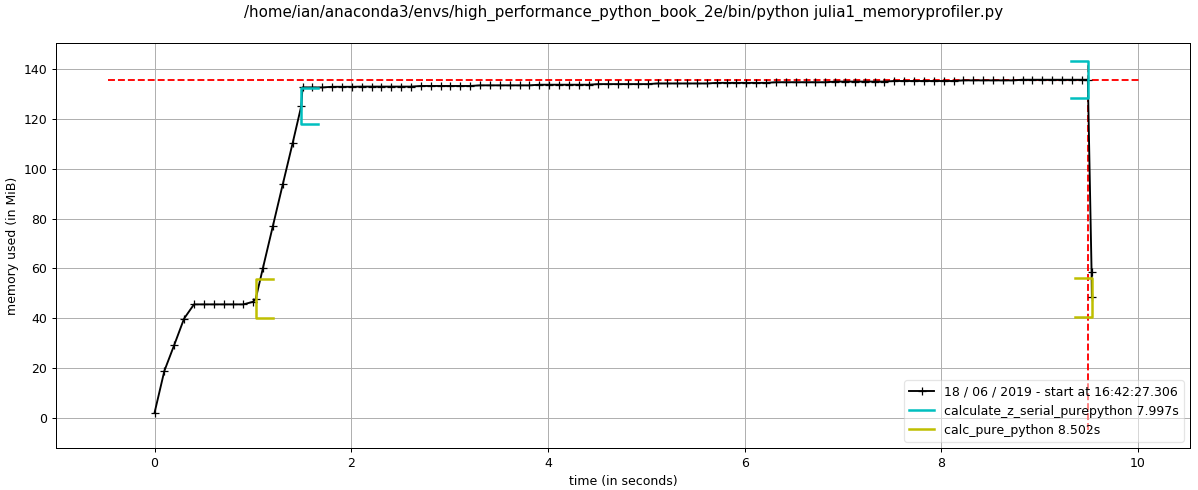

使用mprof的 memory_profiler 报告

除了观察函数级别的行为之外，我们还可以使用上下文管理器添加标签。示例中的代码段 2-11用于生成图中的图形 2-7. 我们可以看到create_output_list标签：它在calculate_z_serial_purepython之后大约1.5秒出现，并导致进程被分配了更多的RAM。然后我们停顿了一下；时间。睡眠（1）是一个人为的增加，使图表更容易理解。

例2-11。使用上下文管理器向mprof图添加标签

In [ ]:
@profile
def calculate_z_serial_purepython(maxiter, zs, cs):
    """Calculate output list using Julia update rule"""
    with profile.timestamp("create_output_list"):
        output = [0] * len(zs)
    time.sleep(1)
    with profile.timestamp("calculate_output"):
        for i in range(len(zs)):
            n = 0
            z = zs[i]
            c = cs[i]
            while n < maxiter and abs(z) < 2:
                z = z * z + c
                n += 1
            output[i] = n
    return output

在运行于大部分图形的 calculate_output 块中，我们看到RAM使用量的线性增长非常缓慢。这将来自内部循环中使用的所有临时数字。使用这些标签确实有助于我们在细粒度的层次上理解内存在哪里被消耗。有趣的是，我们看到了“峰值RAM使用率”这条线——一条垂直虚线，正好在程序终止前的10秒标记之前。这可能是由于垃圾收集器从输出期间使用的临时对象中恢复了一些RAM造成的。

如果我们简化代码并删除zs和cs列表的创建，会发生什么？然后我们必须在 calculate_z_serial_purepython 中计算这些坐标（因此执行相同的工作），但是我们将通过不将它们存储在列表中来节省RAM。您可以在示例中看到代码 2-12.

在图中 2-8，我们看到了行为上的一个重大变化，RAM使用的总范围从140MB下降到60MB，将RAM使用量减少了一半！

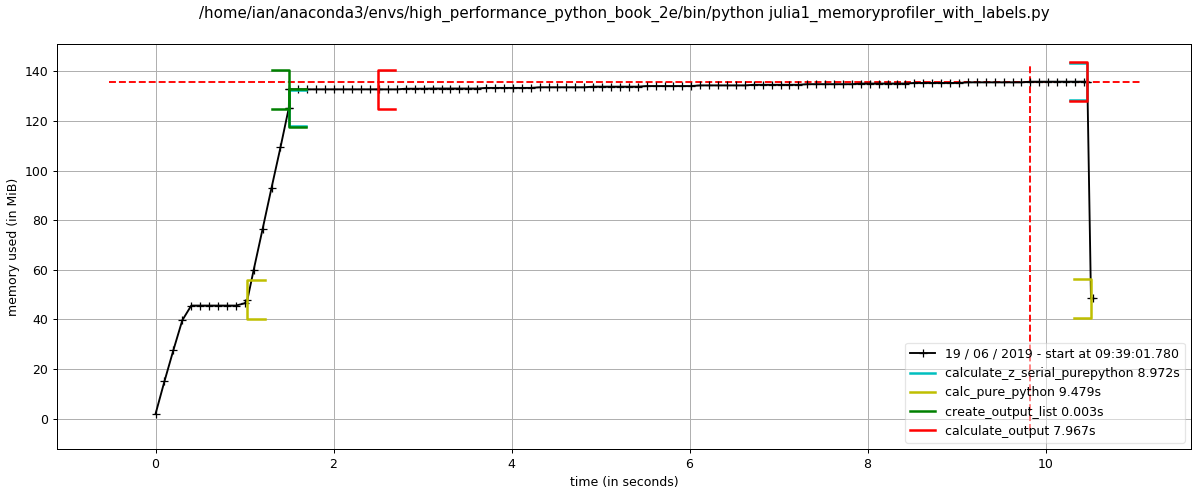

图2-7。使用带标签的mprof的memory_profiler报告

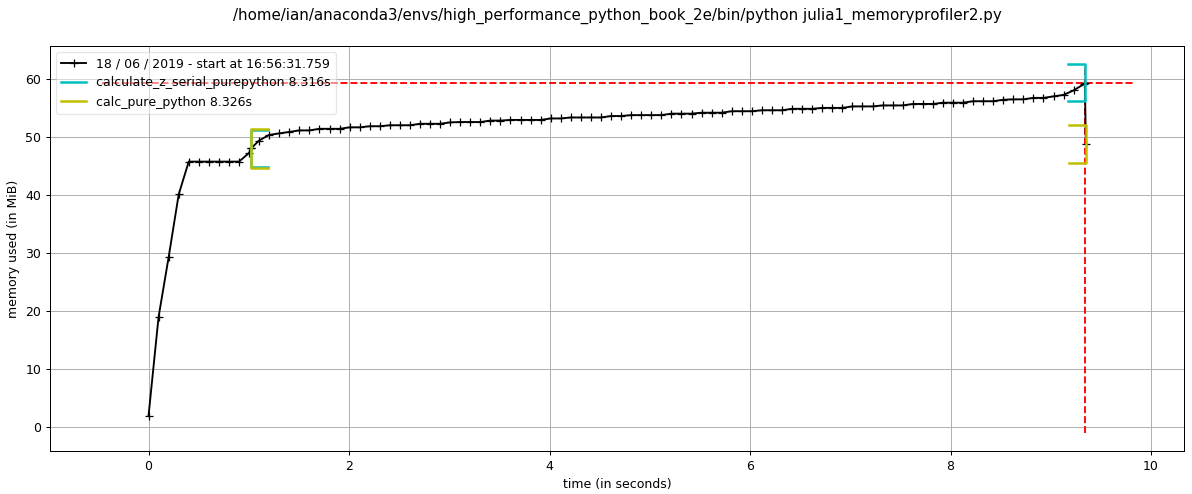

图2-8。删除两个大列表后的memory_profiler

例2-12。动态创建复杂坐标以节省内存

In [ ]:
@profile
def calculate_z_serial_purepython(maxiter, x, y):
    """Calculate output list using Julia update rule"""
    output = []
    for ycoord in y:
        for xcoord in x:
            z = complex(xcoord, ycoord)
            c = complex(c_real, c_imag)
            n = 0
            while n < maxiter and abs(z) < 2:
                z = z * z + c
                n += 1
            output.append(n)
    return output

如果我们想测量几个语句所使用的RAM，我们可以使用IPython magic %memi，它的工作原理与 %timeit 类似。我们将研究如何使用 %memit 来度量列表的内存开销，并讨论如何更有效地使用RAM。

内存分析器通过 --pdb-mmem=XXX 标志为调试大型进程提供了一个有趣的帮助。进程超过XXX MB后，将激活pdb调试器。如果您处于空间受限的环境中，这将直接在代码中发生过多分配的位置将您放入。

### 使用PySpy反测现有进程

pyspy是一个有趣的新采样探查器，它不需要任何代码更改，而是在控制台中用类似top的显示来内省已经运行的Python进程和报告。作为一个采样探查器，它对代码几乎没有运行时影响。它是用Rust编写的，需要提升权限来反省另一个进程。


In [ ]:
!pip install py-spy


在具有长时间运行的过程或复杂安装需求的生产环境中，此工具可能非常有用。它支持Windows、Mac和Linux。使用pip Install py spy安装它（注意名称中的破折号，有一个单独的pyspy项目是不相关的）。如果您的进程已经在运行，您需要使用ps来获取它的进程标识符（PID）；然后可以将其传递到py spy中，如示例所示 2-13.

例2-13。在命令行运行PySpy

在图中 2-9，您将在控制台中看到一个类似顶部显示器的静态图片；它每秒钟更新一次，以显示哪些函数当前占用了大部分时间。

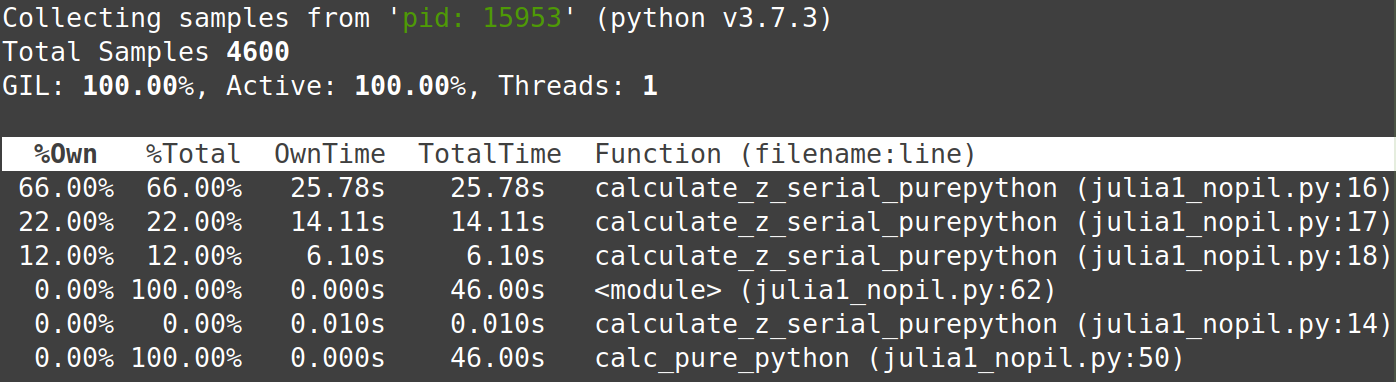

图2-9。使用PySpy反测Python进程

PySpy还可以导出火焰图。在这里，我们将使用$py spy--flame profile.svg--python julia1_nopil.py运行该选项，同时要求PySpy直接运行代码，而不需要PID。你会在图中看到 2-10显示的宽度代表整个程序的运行时，图像向下移动的每一层代表从上面调用的函数。

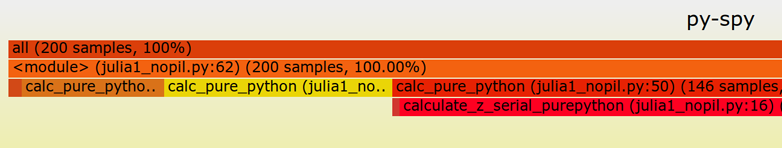

## 字节码：底层

### 使用dis模块检查CPython字节码

dis模块允许我们检查在基于堆栈的CPython虚拟机中运行的底层字节码。了解运行更高级Python代码的虚拟机中发生的事情将有助于理解为什么某些类型的代码比其他类型的代码更快。当您使用Cython这样的工具时，它也会有所帮助，Cython会跳出Python并生成C代码。

dis模块是内置的。您可以向它传递代码或模块，它将打印出反汇编。在示例中 2-14，我们分解了CPU绑定函数的外循环。

In [ ]:
import dis
import julia1_nopil

dis.dis(julia1_nopil.calculate_z_serial_purepython)

如果简洁的话，输出是相当直接的。第一列包含与原始文件相关的行号。第二列包含几个>>符号；这些是代码中其他跳转点的目的地。第三列是操作地址；第四个是操作名。第五列包含操作的参数。第六列包含注释，以帮助将字节码与原始Python参数对齐。

请参阅示例 2-3将字节码与相应的Python代码匹配。字节码从Python第11行开始，将常量值0放入堆栈，然后构建一个元素列表。接下来，它搜索名称空间以找到len函数，将其放入堆栈，再次搜索名称空间以找到zs，然后将其放入堆栈。在Python第12行中，它从堆栈调用len函数，该函数使用堆栈中的zs引用；然后对最后两个参数（zs的长度和单元素列表）应用二进制乘法，并将结果存储在输出中。这是我们现在处理的Python函数的第一行。按照下一个字节码块来理解第二行Python代码（外部for循环）的行为。

在介绍了字节码之后，我们现在可以问：显式地写出一个函数与使用内置函数来执行相同的任务相比，字节码和时间开销是多少？

### 不同的方法，不同的复杂性

使用Python将有多种方式来表达您的想法。一般来说，最明智的选择应该是明确的，但是如果您的经验主要是使用较旧版本的Python或其他编程语言，那么您可能会想到其他方法。其中一些表达想法的方式可能比其他方式慢。

对于大多数代码，您可能更关心可读性而不是速度，这样您的团队就可以高效地编写代码，而不会被性能优异但不透明的代码所迷惑。但是，有时您需要性能（不牺牲可读性）。你可能需要一些速度测试。

请看示例中的两个代码段 2-15. 两者都做相同的工作，但是第一个生成大量额外的Python字节码，这将导致更多的开销。

例2-15。一种简单有效的求和方法

In [ ]:
def fn_expressive(upper=1_000_000):
    total = 0
    for n in range(upper):
        total += n
    return total

def fn_terse(upper=1_000_000):
    return sum(range(upper))

assert fn_expressive() == fn_terse(), "Expect identical results from both functions"

这两个函数都计算一系列整数的和。一个简单的经验法则（但是您必须使用profiling进行备份！）更多的字节码行将比更少的使用内置函数的等效字节码行执行得更慢。在示例中 2-16，我们使用IPython的%timeit魔术函数来度量一组运行的最佳执行时间。fn_terse 比 fn_expressive 快两倍！

例2-16。使用%timeit来检验我们的假设，即使用内置函数应该比编写自己的函数快

In [ ]:
%timeit fn_expressive()

In [ ]:
%timeit fn_terse()

如果我们使用dis模块来研究每个函数的代码，如示例所示 2-17，我们可以看到虚拟机有17行要执行更具表现力的函数，只有6行要执行非常可读但更简洁的第二个函数。

例2-17。使用dis查看两个函数中涉及的字节码指令数

In [ ]:
import dis

dis.dis(fn_expressive)

In [ ]:
dis.dis(fn_terse)

这两个代码块之间的差别是惊人的。在fn_expressive（）中，我们维护两个局部变量，并使用for语句遍历一个列表。for循环将检查是否在每个循环上引发了StopIteration异常。每次迭代应用 total.__add__ 函数，该函数将检查每次迭代中第二个变量（n）的类型。这些检测都增加了一点消耗。

在fn_terse（）中，我们调用了一个优化的C列表理解函数，该函数知道如何生成最终结果而不创建中间Python对象。这要快得多，尽管每次迭代都必须检查被添加到一起的对象的类型，我们查看修复类型的方法，这样就不需要在每次迭代中检查它）。

如前所述，您必须分析您的代码如果您仅仅依靠这个启发式，您将不可避免地在某个时候编写较慢的代码。Python中是否内置了一种更简短、更易读的解决问题的方法，这绝对值得学习。如果是这样的话，它很可能更容易被其他程序员读取，而且它可能会运行得更快。

## 在优化过程中进行单元测试以保持正确性

如果您还没有对代码进行单元测试，那么可能会损害您的长期生产力。

### No-op @profile Decorator

如果代码使用 line_profiler 或 memory_profiler 中的@profile，单元测试将失败，并出现namererror异常。原因是单元测试框架不会将@profile decorator注入本地命名空间。这里显示的no-op decorator解决了这个问题。最简单的方法是将其添加到正在测试的代码块中，并在测试完成后将其删除。
使用no-op decorator，您可以运行测试，而无需修改正在测试的代码。这意味着您可以在每次以概要文件为导向的优化之后运行测试，这样您就永远不会被糟糕的优化步骤所困扰。

假设我们有示例中所示的普通ex.py模块 2-18. 它有一个测试（对于pytest）和一个函数，我们已经用line_profiler或memory_profiler分析过了。

例2-18。我们希望使用@profile的简单函数和测试用例

In [ ]:
import time

def test_some_fn():
    """Check basic behaviors for our function"""
    assert some_fn(2) == 4
    assert some_fn(1) == 1
    assert some_fn(-1) == 1


@profile
def some_fn(useful_input):
    """An expensive function that we wish to both test and profile"""
    # artificial "we're doing something clever and expensive" delay
    time.sleep(1)
    return useful_input ** 2


if __name__ == "__main__":
    print(f"Example call `some_fn(2)` == {some_fn(2)}")

如果我们在代码上运行pytest，我们将得到一个NameError，如示例所示 2-19.

例2-19。一个在测试过程中丢失的装饰器以一种毫无帮助的方式破坏了测试！

In [ ]:
!pytest utility.py

解决方案是在模块的开头添加一个no-op decorator（您可以在完成分析之后删除它）。如果在其中一个名称空间中找不到@profile decorator（因为没有使用line_profiler或memory_profiler），则会添加我们编写的no op版本。如果line_profiler或memory_profiler已经将新函数注入到名称空间中，那么我们的no-op版本将被忽略。

对于line_profiler和memory_profiler，我们可以在示例中添加代码 2-20.

例2-20。在单元测试时向命名空间添加no op@profile修饰符

In [ ]:
# check for line_profiler or memory_profiler in the local scope, both
# are injected by their respective tools or they're absent
# if these tools aren't being used (in which case we need to substitute
# a dummy @profile decorator)
if 'line_profiler' not in dir() and 'profile' not in dir():
    def profile(func):
        return func

添加了no-op修饰符之后，我们现在可以成功地运行pytest，如示例所示 2-21，以及我们的探查器，没有额外的代码更改。

例2-21。使用no-op-decorator，我们可以进行工作测试，并且两个探查器都可以正常工作

In [ ]:
!pytest utility.py

In [ ]:
!python -m memory_profiler utility.py

您可以通过避免使用这些装饰器来节省几分钟的时间，但是一旦您浪费了几个小时来进行错误的优化，从而破坏了您的代码，您就需要将其集成到您的工作流中。

## 成功分析代码的策略

分析需要一些时间和精力。如果将要测试的部分从代码主体中分离出来，您将有更好的机会理解代码。然后，可以对代码进行单元测试以保持正确性，还可以传入真实的捏造数据，以提高效率。

请记住禁用任何基于BIOS的加速器，因为它们只会混淆您的结果。在Ian的笔记本电脑上，如果足够酷的话，Intel Turbo Boost功能可以暂时将CPU加速到高于正常最高速度。这意味着一个冷CPU可能比一个热CPU运行相同的代码块更快。你的操作系统也可以控制时钟的速度——使用电池供电的笔记本电脑可能比使用交流电源的笔记本电脑更积极地控制CPU的速度。为了创建更稳定的基准配置，我们执行以下操作：
- 在BIOS中禁用Turbo Boost。
- 禁用操作系统覆盖SpeedStep的功能（如果允许您控制它，您将在BIOS中找到它）。
- 仅使用交流电源（切勿使用电池电源）。
- 运行实验时禁用备份和Dropbox等后台工具。
- 多次进行实验以获得稳定的测量结果。
- 可能会下降到运行级别1（Unix），以便没有其他任务正在运行。
- 重新启动并重新运行实验以双重确认结果。

尝试假设代码的预期行为，然后验证（或反驳！）具有分析步骤结果的假设。您的选择不会改变（您应该只通过使用概要分析的结果来驱动您的决策），但是您对代码的直观理解将会提高，这将在未来的项目中得到回报，因为您将更有可能做出性能决定。当然，您将在运行时通过分析来验证这些性能决策。

不要吝啬于准备工作。如果您试图在更大的项目中对代码进行深入的性能测试，而不将其与更大的项目分开，那么您很可能会看到一些副作用，这些副作用会影响您的工作。在进行细粒度更改时，对更大的项目进行单元测试可能会更困难，这可能会进一步阻碍您的工作。副作用可能包括影响CPU和内存使用率以及网络和磁盘活动的其他线程和进程，这会扭曲结果。

当然，您已经在使用源代码控制（例如，Git或Mercurial），因此您可以在不同的分支中运行多个实验，而不会丢失“运行良好的版本”。如果您不使用源代码控制，请帮自己一个大忙，并开始这样做！

对于web服务器，调查dowser和dozer；您可以使用这些来实时可视化命名空间中对象的行为。如果可能的话，一定要考虑将要测试的代码从主web应用程序中分离出来，因为这将使分析变得非常容易。

确保单元测试在所分析的代码中使用所有代码路径。在基准测试中使用的任何你没有测试的东西都可能会导致微妙的错误，从而减慢你的进度。使用coverage.py确认测试覆盖了所有代码路径。

单元测试生成大量数值输出的复杂代码段可能很困难。不要害怕输出结果的文本文件来运行diff或使用pickled对象。对于数值优化问题，Ian喜欢创建浮点数的长文本文件，并使用diff小舍入错误立即出现，即使它们在输出中很少出现。

如果您的代码可能由于细微的更改而受到数字舍入问题的影响，那么您最好使用一个可以用于前后比较的大输出。舍入错误的一个原因是CPU寄存器和主存之间浮点精度的差异。在不同的代码路径中运行代码可能会导致细微的舍入错误，这可能会使您以后感到困惑—最好在错误发生时立即注意到这一点。

显然，在分析和优化时使用源代码控制工具是有意义的。分支是廉价的，它会保持你的理智。

## 总结

在研究了分析技术之后，您应该拥有识别代码中CPU和RAM使用瓶颈所需的所有工具。下一步，我们将研究Python如何实现最常见的容器，以便您在表示更大的数据集合时做出明智的决定。